# **Atividade Prática**
<font size=3>

- **Tema:** Problema de busca.
- **Prazo de entrega:** 19 de Setembro.

**Envie** a atividade pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeUFqt61PGKmPpD6AEIOIO6XzVi71ZmuWxeWH0JfMFWeaSMnQ/viewform?usp=header).

---

ALUNO: João Marcelo de Souza (20220030819)

## **Enunciado:**
<font size=3>
    
Baseado no **_notebook_ 3.2** ("Exemplo de Busca em Largura"), desenvolva duas soluções para encontrar uma rota em um mapa: uma com um algoritmo de **busca desinformada** e outra com um de **busca informada**.\
O módulo `toolbox` apresenta todas as implementações necessárias de funções e classes para a realização desta atividade.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

ModuleNotFoundError: No module named 'google'

In [2]:
pip install osmnx

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ------------------------------ --------- 1.6/2.0 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 7.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 8.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   ---- ----------------------------------- 2.1/19.2 MB 9.8 MB/s eta 0:00:02
   -------- ------------------------------- 4.2/19.2 MB 9.7 MB/s eta 0:00:02
   ------------ --------------------------- 5.8/19.2 MB 9.3 MB/s eta 0:00:02
   ---------------- ----------------------- 8.1/19.2 MB 9.3 MB/s eta 0:00:02
   -------------------- ------------------- 10.0/19.2 MB 9.3 MB/s eta 0:00:01
   ------------------------ --------------- 11.8/19.2 MB 9.2 MB/s eta 0:00:01
   ---------------------------- ----------- 13.9/19.2 MB 9.2 MB/s eta 0:00:01
   ------------------


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import osmnx as ox
import numpy as np

---

### **1. Questão — Busca Desinformada:**
#### **1.1 Implementação:**
<font size=3>

- Escolha um algoritmo de **busca desinformada** (que não seja *Busca em Largura*);

- Defina as coordenadas de origem e destino (*no Google Maps, ao clinar em uma posição no mapa com o botão direito, as coordenadas aparecem em um aba*);

- Defina o modo de percurso ("*drive*", "*walk*", "*bike*" ou "*all*");

- Utilize a função `uninformed_search` de `toolbox` para definir o modelo e as variáveis. Esta função irá executar a busca e plotar o mapa com a solução.
  

##Gerando o Grafo do Mapa para a realização da atividade

In [ ]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/IMD3001 - Introdução à Inteligência Artificial/1ª unidade')


In [ ]:
from toolbox import Node, uninformed_search

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#from toolbox import Node, uninformed_search
def haversine(lat1, lon1, lat2, lon2):

    """Distância aproximada em metros entre dois pares de (latitude, longitude)."""

    R = 6371000.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dl   = np.deg2rad(lon2 - lon1)

    a = np.sin(dphi/2.0)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2.0)**2

    return 2*R*np.arcsin(np.sqrt(a))


def graph(lat_o, lon_o, lat_d, lon_d, mode="walk", margin=500):

    """
    Baixa um grafo OSM que cobre a área entre origem e destino, com margem extra.
    mode: 'drive' | 'walk' | 'bike' | 'all'
    """

    dist = haversine(lat_o, lon_o, lat_d, lon_d) + margin

    lat_c = (lat_o + lat_d)/2
    lon_c = (lon_o + lon_d)/2

    return ox.graph_from_point(center_point=(lat_c, lon_c), dist=dist, network_type=mode, simplify=True)


def edges2streets(G, path_nodes):

    """
    Converte arestas do grafo para nomes de ruas aproximadas.
    """

    streets = []
    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        data_options = G.get_edge_data(u, v)

        if not data_options: # mão oposta, se necessário
            data_options = G.get_edge_data(v, u)
        if not data_options:
            streets.append("(desconhecida)")
            continue

        data = list(data_options.values())[0]
        name = data.get('name')

        if isinstance(name, list) and name:
            streets.append(name[0])
        elif isinstance(name, str) and name.strip():
            streets.append(name)
        else:
            streets.append("(sem nome)")

    return streets




##Implementando uma busca em profundidade

In [ ]:
from collections import deque

class Problem:

    def __init__(self, initial_state, actions, transition_model, goal_test, step_cost):

        self.initial_state = initial_state
        self.actions = actions                    # função actions(state) -> iterável de actions
        self.transition_model = transition_model  # função (state, action) -> new_state
        self.goal_test = goal_test                # função (state) -> bool
        self.step_cost = step_cost                # função (state, action) -> custo


class Node:

    def __init__(self, problem, parent=None, action=None):

        self.parent = parent
        self.action = action

        if parent is None:
            self.state = problem.initial_state
            self.path_cost = 0.0
        else:
            self.state = problem.transition_model(parent.state, action)
            self.path_cost = parent.path_cost + problem.step_cost(parent.state, action)


    def __eq__(self, other):

        '''
        Este método possibilita usar o operador == para verificar se dois
        objetos da classe Node apresentam o mesmo estado.
        '''

        return isinstance(other, Node) and self.state == other.state


    def __hash__(self):

        '''
        Este método define como um objeto será convertido em um número inteiro (hash code)
        que o identifica de forma única em coleções baseadas em hashing, como set e dict.
        '''

        return hash(self.state)

class DepthFirstSearch:

      def __init__(self, problem):
          self.problem = problem
          self.frontier = []
          self.explored = set()

      def search(self):
          root = Node(problem=self.problem)

          if self.problem.goal_test(root.state):
              return root

          self.frontier.append(root)

          while self.frontier:
              node = self.frontier.pop()

              # evita expandir o mesmo estado múltiplas vezes:
              if node in self.explored:
                  continue

              self.explored.add(node)

              if self.problem.goal_test(node.state):
                  return node

              # expansão do nó:
              for action in reversed(list(self.problem.actions(node.state))):
                  child = Node(self.problem, node, action)

                  if (child not in self.explored) and (child not in self.frontier):
                      self.frontier.append(child)

          return None # solução não encontrada





In [ ]:
class MapProblem(Problem):

    """
    Estados = IDs de nós do grafo OSMNX (NetworkX).
    Ações(state) = nós vizinhos alcançáveis por uma aresta (sucessores).
    Modelo de transição(state, action) = action (vizinho escolhido).
    Custo de passo = 1 (BFS -> menor nº de arestas).
    """

    def __init__(self, G, start_node, goal_node):

        self.G = G
        self.goal_node = goal_node

        super().__init__(initial_state = start_node,
                         actions = self.actions_fn,
                         transition_model = self.transition_fn,
                         goal_test = self.goal_test_fn,
                         step_cost = self.step_cost_fn)


    def actions_fn(self, state):

        '''
        Para o opção "drive", OSMnx retorna um grafo direcionado, com nós "sucessores".
        Já a opção "walk", o grafo é não-direcionado, com nós "vizinhos".
        '''

        return self.G.successors(state) if hasattr(self.G, "successors") else self.G.neighbors(state)


    def transition_fn(self, state, action):
        return action  # ação é o próprio vizinho


    def goal_test_fn(self, state):
        return state == self.goal_node


    def step_cost_fn(self, state, action):
        return 1.0  # cada aresta custa 1



Implementando uma busca, pela rota de carro do Restaurante Universitário (RU) Até o Natal Shopping

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
##coordenadas do restaurante universitário
lat_origin, lon_origin = -5.8330588239177015, -35.2039402893459
##coordenadas do natal shopping
lat_goal, lon_goal = -5.841848583389055, -35.21046951398413
mode = "drive"  #carro

G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode=mode, margin= 600)

start = ox.nearest_nodes(G, lon_origin, lat_origin)
goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

print("Start node ID:", start)
print("Goal node ID:", goal)

Start node ID: 505104153
Goal node ID: 7207892787


In [ ]:
problem = MapProblem(G, start_node=start, goal_node=goal)

# definindo o modelo de busca (busca em profunidade):
bfs = DepthFirstSearch(problem)

# inicializando a busca:
goal_node = bfs.search()

In [ ]:
# extraindo o caminho de nós da solução da busca:
node = goal_node
path = []

while node is not None:
    path.append(node.state)
    node = node.parent

path_nodes = list(reversed(path))

print(f"# Nós no caminho (BFS): {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}")

# Nós no caminho (BFS): 192  |  # arestas: 191


In [ ]:
# imprimindo o nome das ruas da rota:
seq_ruas = edges2streets(G, path_nodes)

print("Ruas percorridas (aproximadamente):\n")
for i, r in enumerate(seq_ruas, 1):
    print(f"{i:02d}. {r}")


Ruas percorridas (aproximadamente):

01. Rua Haroldo de Almeida
02. Rua da Bronzita
03. Rua da Bronzita
04. Rua Apolônio de Souza
05. Avenida Capitão Mor-Gouveia
06. (sem nome)
07. (sem nome)
08. (sem nome)
09. Avenida Capitão Mor-Gouveia
10. Avenida Capitão Mor-Gouveia
11. Avenida Capitão Mor-Gouveia
12. Avenida Capitão Mor-Gouveia
13. Avenida Capitão Mor-Gouveia
14. (sem nome)
15. Avenida Capitão Mor-Gouveia
16. Rua da Sheelita
17. Rua da Sheelita
18. Rua da Esmeralda
19. Avenida Senador Salgado Filho
20. Rua do Amianto
21. Rua do Amianto
22. Rua do Mercúrio
23. Rua da Esmeralda
24. Rua da Esmeralda
25. Rua da Esmeralda
26. Rua da Fluorita
27. Avenida Capitão Mor-Gouveia
28. Avenida Capitão Mor-Gouveia
29. (sem nome)
30. Rua do Sal
31. Rua do Sal
32. Rua do Antimônio
33. (sem nome)
34. Anel Viário da UFRN
35. Anel Viário da UFRN
36. Anel Viário da UFRN
37. Anel Viário da UFRN
38. Anel Viário da UFRN
39. Anel Viário da UFRN
40. Avenida Odilon Gomes de Lima
41. Avenida Odilon Gomes de 

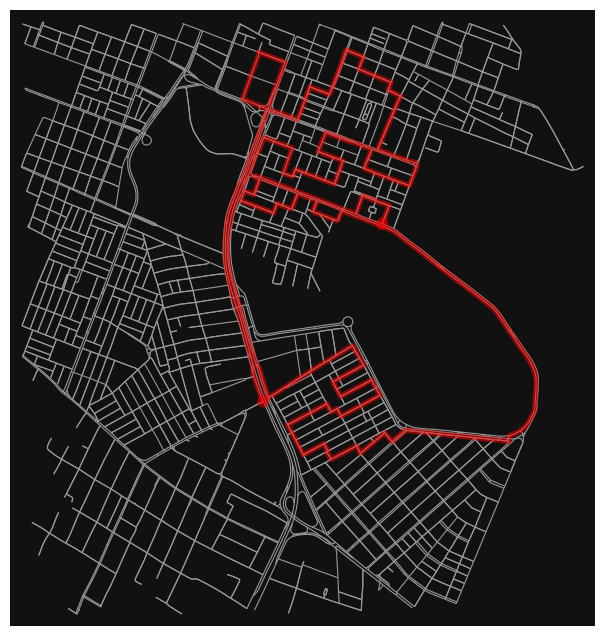

In [ ]:
##plotando o mapa da solução
fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0, edge_linewidth=0.8)
ox.plot_graph_route(G, path_nodes, ax=ax, route_linewidth=4, orig_dest_size=80, show=False, close=False)
plt.show()

#### **1.2 Análise:**
<font size=3>
    
Em uma **célula de markdown** compare o algoritmo que você escolheu com a **Busca em Largura (BFS)**, analisando os seguintes critérios:

- **Estrutura da Fronteira:** Qual estrutura de dados a fronteira utiliza (ex: Fila FIFO, Pilha LIFO, Fila de Prioridades)?

- **Otimalidade:** O seu algoritmo **garante** que a rota encontrada é a mais curta (com o menor número de ruas)? Justifique.

- **Complexidade:** Em geral, qual dos dois algoritmos (o seu ou o BFS) você espera que use mais memória para este problema de mapa? Por quê?
  

###Comparativo entre busca em Largura (BFS) e busca por profundidade

- Estrutura da fronteira:
   
   - Bfs utiliza Fila FIFO. O primeiro nó inserido na fronteira é o primeiro a ser expandido
   - Busca por profundidade utiliza a pilha LIFO. o ultimo nó inserido é o primeiro a ser expandido

*   Otimalidade

    - **BFS**- Sim, pois o custo de cada aresta é o mesmo
    - **DFS** - Não, ele pode encontrar uma solução rapidamente, mais não garante que seja a menor rota, podendo gerar caminhos mais longos desnecessáriamente

*   Complexidade

    -  **BFS**: Pode usar muito mais memória, pois armazena todos os nós de um nível antes de expandir o proximo
    - **DFS**: Utiliza menos memória que a BFS, pois precisa armazenar apenas os nós ao longo do camihno atual





---

### **2. Questão — Busca Informada:**
#### **2.1 Implementação:**
<font size=3>

- Escolha um algoritmo de **busca informada**;

- Defina as coordenadas de origem e destino (diferença das usadas na **questão 1**);

- Defina o modo de percurso (diferença do usado na **questão 1**);

- Utilize a função `informed_search` de `toolbox` para definir o modelo, a função heurística e as variáveis. Esta função irá executar a busca e plotar o mapa com a solução.


**Implementando uma busca informada do tipo busca gananciosa pela melhor escolha**

In [ ]:
##from toolbox import haversine, informed_search

##implementando o algoritmo
import heapq

class GreedyBestFirstSearch:

    def __init__(self, problem, heuristic):

        self.problem = problem
        self.h = heuristic

    def search(self):

        root = Node4Heap(problem=self.problem)
        frontier = [(self.h(root.state), root)]
        explored = set()

        while frontier:
            priority, node = heapq.heappop(frontier)

            if self.problem.goal_test(node.state):
                return node

            explored.add(node.state)

            # expande nó:
            for action in self.problem.actions(node.state):
                child = Node4Heap(self.problem, node, action)

                if child.state not in explored:
                    if not any(child.state == item[1].state for item in frontier):
                        priority = self.h(child.state)
                        heapq.heappush(frontier, (priority, child))

        return None


class Node4Heap(Node):

    def __init__(self, problem, parent=None, action=None):
        super().__init__(problem, parent, action)

    def __lt__(self, other):
        return self.path_cost < other.path_cost


**Utilizando a função heurística**

In [ ]:
class Heuristic:

    def __init__(self, graph, goal_state):

        self.G = graph
        self.goal = goal_state

    def fn(self, state):

        node_coords = (self.G.nodes[state]['y'], self.G.nodes[state]['x'])
        goal_coords = (self.G.nodes[self.goal]['y'], self.G.nodes[self.goal]['x'])

        return haversine(node_coords[0], node_coords[1], goal_coords[0], goal_coords[1])

Definindo o modelo por meio da função "informed_search", que será a busca do tipo **gananciosa**

In [ ]:
def informed_search(Model, heuristic_class, lat_origin, lon_origin, lat_goal, lon_goal, mode):

    G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode=mode, margin=600)

    # definindo os nós mais próximos das coordenadas:
    start = ox.nearest_nodes(G, lon_origin, lat_origin)
    goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

    print("Start node ID:", start)
    print("Goal node ID:", goal)


Exemplo prático da busca escolhida, fazendo uma rota "a pé" da Escola de ciências e tecnologia (ECT-UFRN) até a biblioteca da UFRN

In [ ]:
##ect até biblioteca
lat_origin, lon_origin = -5.843076012262469, -35.19617906122851   # Origem
lat_goal, lon_goal = -5.839105607368445, -35.19308915678429

mode = "walk"

# Executando a busca informada com Busca Gananciosa
informed_search(GreedyBestFirstSearch, Heuristic,
                lat_origin, lon_origin, lat_goal, lon_goal, mode)


Start node ID: 4907867752
Goal node ID: 926531690


**Definindo as Funções**

In [ ]:
# definindo o problema de busca:
problem = MapProblem(G, start_node=start, goal_node=goal)

# definindo a função heurística:
heuristic = Heuristic(G, goal)

# definindo o modelo de busca:
model = GreedyBestFirstSearch(problem, heuristic.fn)

# inicializando a busca:
goal_node = model.search()

# extraindo o caminho de nós da solução da busca:
node = goal_node
path = []

while node is not None:
    path.append(node.state)
    node = node.parent

path_nodes = list(reversed(path))

print(f"\n# Nós no caminho: {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}\n")
print(f"# Path nodes: {path_nodes}\n")



# Nós no caminho: 53  |  # arestas: 52

# Path nodes: [505104153, 505103938, 505103991, 502606124, 12902213662, 12891914402, 7189445867, 503787973, 12902213663, 502845281, 1949002677, 1949002678, 1387156176, 1387156245, 501838307, 500986639, 784697922, 784697937, 501825771, 500986659, 784697943, 784697949, 1387156481, 501033902, 501834757, 6370922831, 501834727, 501834720, 501834788, 501834724, 501834789, 501834760, 501834787, 501834711, 501834764, 501834746, 501834747, 501834804, 505084221, 502310485, 505084246, 502539145, 7207368739, 3858048276, 505086847, 501791821, 500973601, 529747755, 529747768, 529747769, 529747758, 529747760, 7207892787]



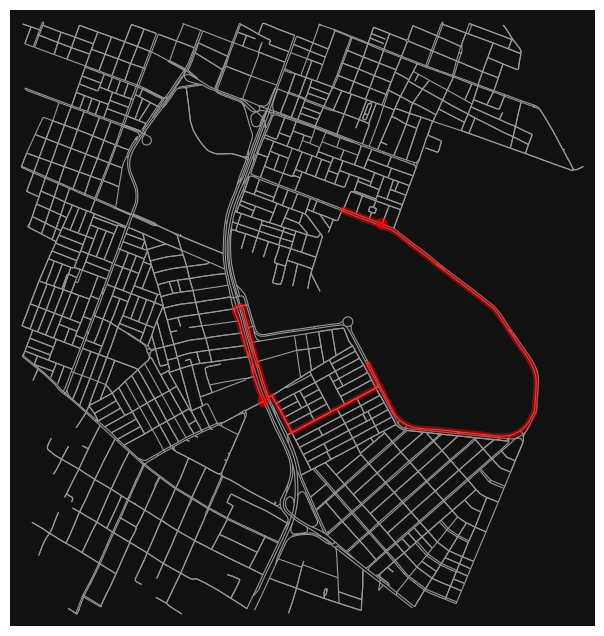

In [ ]:
# plotando o mapa e rota de solução:
fig, ax = ox.plot_graph(G, show=False, close=False, node_size=0, edge_linewidth=0.8)
ox.plot_graph_route(G, path_nodes, ax=ax, route_linewidth=4, orig_dest_size=80, show=False, close=False)
plt.show()



#### **2.2 Análise:**
<font size=3>

Em uma **célula de markdown** descreva as principais características do algoritmo que você escolheu, respondendo:

- **Heurística:** Qual foi a função heurística `h(n)` que você utilizou para guiar a busca?

- **Função de Avaliação:** Como o seu algoritmo prioriza os nós na fronteira? Ele usa apenas a heurística $h(n)$, como a Busca Gananciosa, ou uma combinação de custo e heurística $f(n) = g(n) + h(n)$, como o A*?

- **Otimalidade:** A rota encontrada pelo seu algoritmo é **garantidamente** a de menor custo (menor distância total)? Explique como a sua escolha de heurística e função de avaliação afeta essa garantia.

  

###Analise:



*   **Heurística:** A função heurística utilizada foi a distância "Haversine" entre o nó atual e o nó objetivo (as duas coordenadas no mapa). Essa função estima a distância em linha reta entre dois pontos do mapa.

*  **Função de Avaliação:** Na busca gananciosa, a prioridade dos nós na fronteira é dada apenas pelo valor da Heurística.

*   **Otimilidade:** A busca gananciosa não garante encontrar a rota de menor custo total



